In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv('weight-height.csv')
df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
8550,Female,60.483946,110.565497
8551,Female,63.423372,129.921671
8552,Female,65.584057,155.942671
8553,Female,67.429971,151.678405


In [4]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

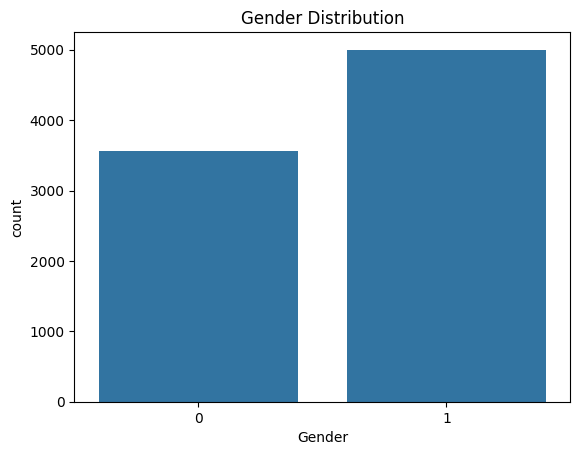

In [5]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

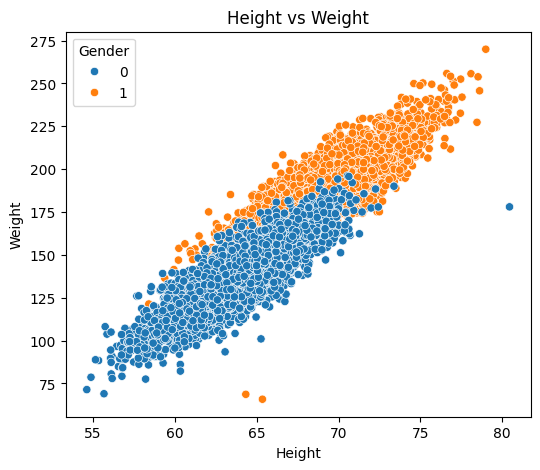

In [6]:
plt.figure(figsize=(6,5))
sns.scatterplot(x='Height', y='Weight', hue='Gender', data=df)
plt.title("Height vs Weight")
plt.show()

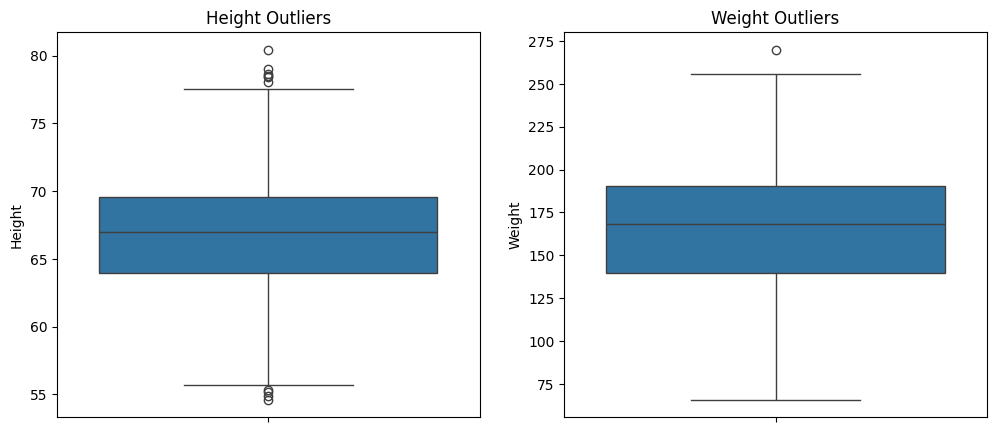

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df['Height'])
plt.title("Height Outliers")

plt.subplot(1,2,2)
sns.boxplot(y=df['Weight'])
plt.title("Weight Outliers")

plt.show()

In [8]:
Q1 = df[['Height','Weight']].quantile(0.25)
Q3 = df[['Height','Weight']].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df[['Height','Weight']] < (Q1 - 1.5 * IQR)) |
          (df[['Height','Weight']] > (Q3 + 1.5 * IQR))).any(axis=1)]

In [9]:
X = df[['Height','Weight']]
y = df['Gender']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [13]:
y_pred_lr = lr.predict(X_test)
y_pred_knn = knn.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

Logistic Regression Accuracy: 0.9245172615564657
KNN Accuracy: 0.9052077238150965


In [14]:
print("LR Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

LR Confusion Matrix:
 [[643  67]
 [ 62 937]]
KNN Confusion Matrix:
 [[620  90]
 [ 72 927]]


In [15]:
print("LR Report:\n", classification_report(y_test, y_pred_lr))
print("KNN Report:\n", classification_report(y_test, y_pred_knn))

LR Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       710
           1       0.93      0.94      0.94       999

    accuracy                           0.92      1709
   macro avg       0.92      0.92      0.92      1709
weighted avg       0.92      0.92      0.92      1709

KNN Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88       710
           1       0.91      0.93      0.92       999

    accuracy                           0.91      1709
   macro avg       0.90      0.90      0.90      1709
weighted avg       0.91      0.91      0.91      1709



In [16]:
lr_cv = cross_val_score(lr, X, y, cv=5)
knn_cv = cross_val_score(knn, X, y, cv=5)

print("LR CV Mean:", lr_cv.mean())
print("KNN CV Mean:", knn_cv.mean())

LR CV Mean: 0.9180807489760093
KNN CV Mean: 0.9090696313633704


In [17]:
param_grid = {
    'n_neighbors': range(1,31),
    'weights': ['uniform', 'distance']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best KNN Parameters:", grid.best_params_)

Best KNN Parameters: {'n_neighbors': 11, 'weights': 'uniform'}


In [18]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']
}

grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=5)
grid_lr.fit(X_train, y_train)

print("Best LR Parameters:", grid_lr.best_params_)

Best LR Parameters: {'C': 100, 'solver': 'liblinear'}


In [19]:
best_model = grid.best_estimator_  # or grid_lr.best_estimator_

In [20]:
best_model

,n_neighbors,11
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


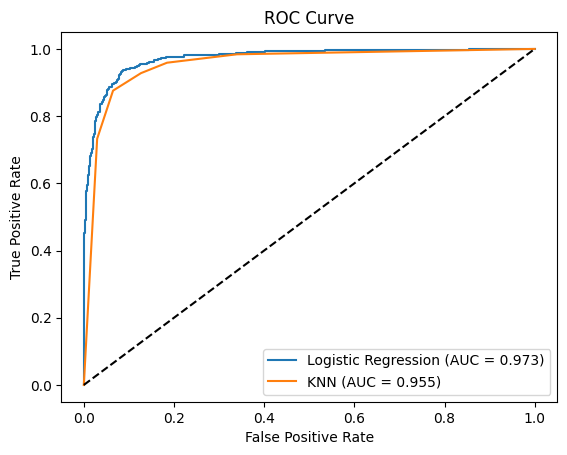

In [22]:
# =========================
# 3️⃣ ROC Curve
# =========================
from sklearn.metrics import roc_curve, auc
y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_knn = knn.predict_proba(X_test)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression (AUC = %.3f)" % auc(fpr_lr, tpr_lr))
plt.plot(fpr_knn, tpr_knn, label="KNN (AUC = %.3f)" % auc(fpr_knn, tpr_knn))
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


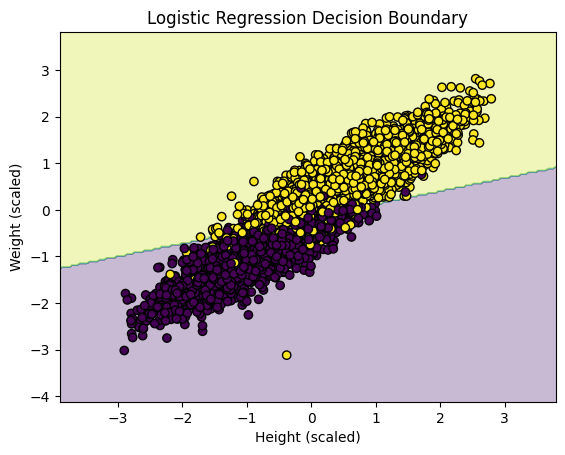

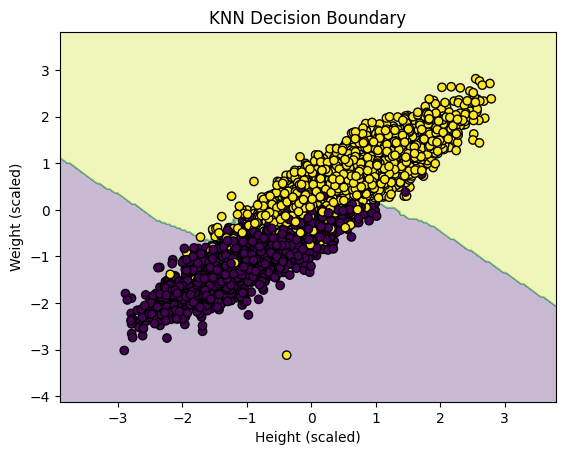

In [23]:
# 4️⃣ Decision Boundary
# =========================
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
    plt.title(title)
    plt.xlabel("Height (scaled)")
    plt.ylabel("Weight (scaled)")
    plt.show()

plot_decision_boundary(lr, X_train, y_train, "Logistic Regression Decision Boundary")
plot_decision_boundary(knn, X_train, y_train, "KNN Decision Boundary")